<a href="https://colab.research.google.com/github/Luisafrodriguezo1/Ejercicio_-Segmentacion-/blob/main/Ejercicio_SAM_UPRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación (SAM y GeoAI)

## Caso de Estudio: Segmentación zona de Pradera

En este caso de estudio se utilizará la herramienta Samgeo, una interfaz geoespacial del modelo de inteligencia artificial Segment Anything Model (SAM), desarrollada por el investigador Qiusheng Wu. Esta herramienta permite aplicar segmentación automática sobre imágenes satelitales georeferenciadas, integrando visión por computador con análisis espacial.

Se instala el paquete llamado segment-geospatial, el cual está relacionado con Segment Anything Model (SAM) adaptado para aplicaciones geoespaciales.

 📌 [Documentación de Samgeo](https://samgeo.gishub.org/)



In [2]:
pip install segment-geospatial

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 82.7 MB/s eta 0:00:00


Se configura el entorno para realizar tareas de segmentación geoespacial, manipulación y visualización de datos ráster y vectoriales.

In [3]:
import rasterio
from samgeo import SamGeo
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
import geopandas as gpd

There was an error importing sam2. To use SAMGeo 2, install it as:
	pip install segment-geospatial[samgeo2]


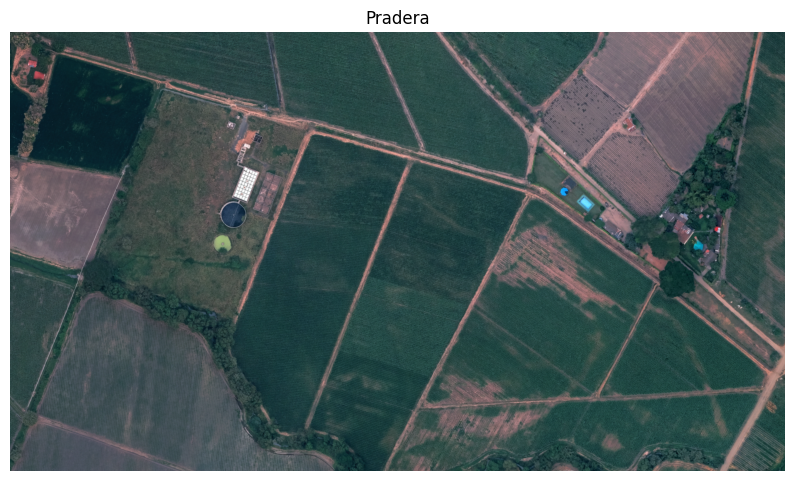

In [4]:
image = 'https://github.com/Luisafrodriguezo1/Ejercicio_-Segmentacion-/raw/refs/heads/main/Pradera.tif'
with rasterio.open(image) as src:
    # Leer las tres primeras bandas del raster
    band1 = src.read(1)
    band2 = src.read(2)
    band3 = src.read(3)

    # Obtener la transformación de afinidad para georreferenciar el raster
    transform = src.transform

    rgb_image = np.dstack((band1, band2, band3))

    # Crear una figura para la visualización
    plt.figure(figsize=(10, 10))

    # Mostrar la imagen RGB utilizando la función show de rasterio
    plt.imshow(rgb_image)
    plt.title("Pradera")
    plt.axis('off')


    plt.show()

In [5]:
%%capture
!wget -O Pradera.tif "https://github.com/Luisafrodriguezo1/Ejercicio_-Segmentacion-/raw/refs/heads/main/Pradera.tif"

Se realizará la segmentación de una zona en el municipio de Pradera, utilizando el archivo ráster Pradera.tif como fuente de imagen.

###  Carga del modelo SAM

Se carga el modelo **SAM** utilizando la clase `SamGeo`, con los siguientes parámetros:

- `model_type="vita_h"`: Vision TransformerHuge es el modelo más grande y preciso, pero también el que más memoria y tiempo de cómputo exige..
- `checkpoint="sam_vit_h_4b8939.pth"`: ruta al archivo de pesos del modelo preentrenado de SAM.
- `sam_kwargs=None`:None, SamGeo decide cómo cargar SAM (normalmente:Usa GPU si hay CUDA disponible.Si no, cae a CPU).
- `points_per_side=128`: Define la **densidad de puntos** para segmentar; a mayor valor, mayor detalle.
- `pred_iou_thresh=0.8`: Umbral mínimo de **IoU (intersección sobre unión)** para conservar predicciones confiables.
- `stability_score_thresh=0.8`: Umbral de **estabilidad** que filtra predicciones inestables.

In [6]:
sam = SamGeo(
    model_type="vit_h",
    checkpoint="sam_vit_h_4b8939.pth",
    sam_kwargs=None,
    points_per_side=128,
    pred_iou_threshold=0.8,
    stability_score_threshold=0.8,
)

Model checkpoint for vit_h not found.


Downloading...
From: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
To: /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth
100%|██████████| 2.56G/2.56G [00:21<00:00, 118MB/s]


Se definen rutas de archivos que usarás luego en el procesamiento

In [7]:
image="/content/Pradera.tif"
# ruta de la mask
mask="/content/pradera_mask.tif"
# ruta shape
shapemask="/content/pradera_SAM.tif"


La función `sam.generate()` aplica el modelo SAM sobre la imagen para producir una máscara segmentada.
- `batch=True`: Procesa la imagen por bloques/tiles
- `foreground=True`:la máscara generada debe marcar los objetos segmentados como 1 (o 255) y el fondo como 0.
- `erosion_kernel=(3,3)`Aplica una erosión morfológica de tamaño 3×3 a la máscara para limpiar bordes,quitar ruido pequeño y suavizar píxeles aislados

In [8]:
sam.generate(image, mask, batch=True, foreground=True, erosion_kernel=(3,3), mask_multiplier=255)

100%|██████████| 24/24 [02:50<00:00,  7.12s/it]


Se convierte un archivo ráster de máscaras segmentadas en un archivo vectorial (shapefile).

In [9]:
shapemask="/content/pradera_SAM"
sam.tiff_to_vector(mask, shapemask)

Creamos la función `graficar_mascara_sobre_raster()` que muestra un ráster RGB** (como una ortofoto) y superpone una capa vectorial (por ejemplo, máscaras segmentadas) para visualización conjunta.

In [10]:
def graficar_mascara_sobre_raster(raster, vector, titulo):
    """
    Visualiza un ráster RGB con una capa vectorial superpuesta.

    Parámetros:
    - raster (str): Ruta al archivo .tif.
    - vector (str): Ruta al archivo .shp o .geojson.
    - titulo (str): Título del gráfico.
    """
    # Leer raster RGB
    with rasterio.open(raster) as src:
        rgb = np.dstack([src.read(i) for i in (1, 2, 3)])
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    # Normalizar si es necesario
    if rgb.max() > 255:
        rgb = rgb / 65535.0
    else:
        rgb = rgb / 255.0

    # Leer vector
    gdf = gpd.read_file(vector)

    # Visualizar
    plt.figure(figsize=(12, 12))
    plt.imshow(rgb, extent=extent)
    gdf.plot(ax=plt.gca(), facecolor='none', edgecolor='lime', linewidth=1)
    plt.title(titulo)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

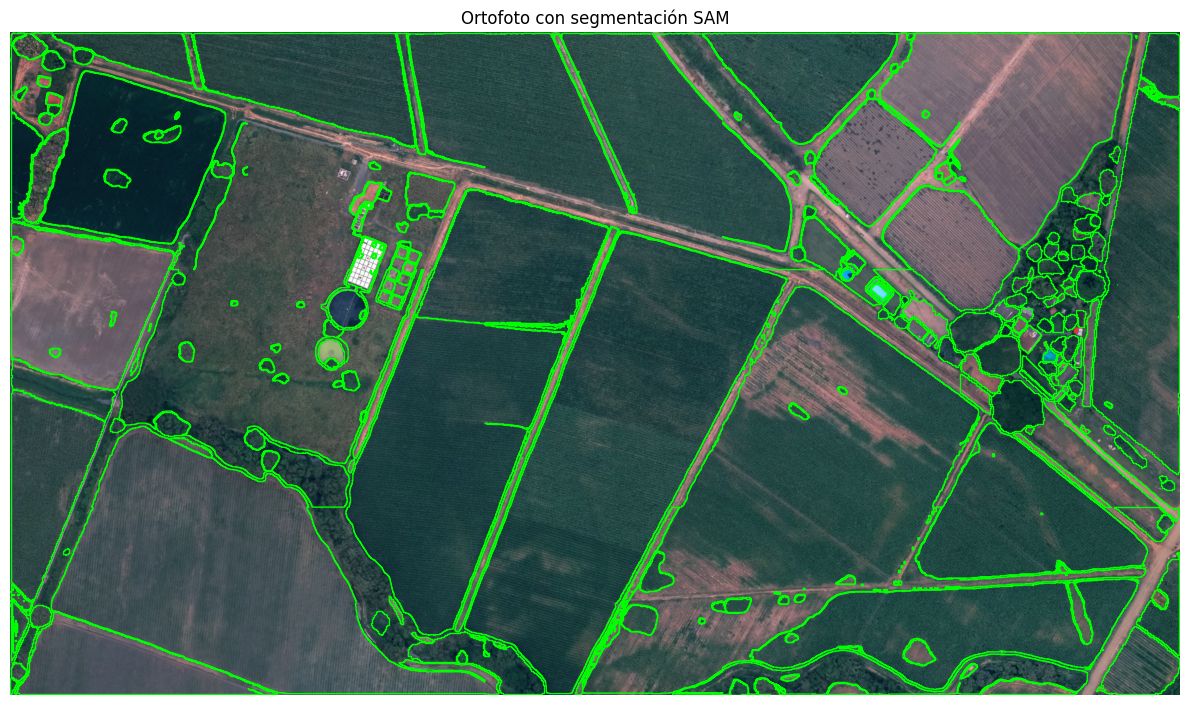

In [16]:
graficar_mascara_sobre_raster(
    raster=image,
    vector="/content/pradera_SAM/pradera_SAM.shp",
    titulo="Ortofoto con segmentación SAM"
)


## Caso de Estudio: Segmentación Geoespacial con Samgeo en el Municipio de Guasca



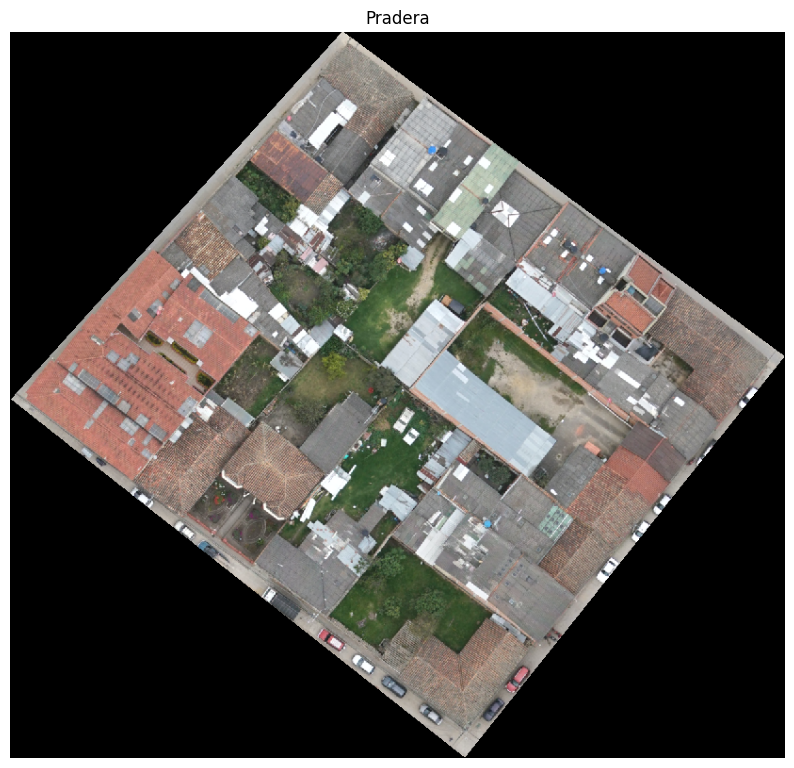

In [11]:
guasca_test="https://github.com/Luisafrodriguezo1/Ejercicio_-Segmentacion-/raw/refs/heads/main/Orto_guasca_test.tif"
with rasterio.open(guasca_test) as src:
    # Leer las tres primeras bandas del raster
    band1 = src.read(1)
    band2 = src.read(2)
    band3 = src.read(3)

    # Obtener la transformación de afinidad para georreferenciar el raster
    transform = src.transform

    rgb_image = np.dstack((band1, band2, band3))

    # Crear una figura para la visualización
    plt.figure(figsize=(10, 10))

    # Mostrar la imagen RGB utilizando la función show de rasterio
    plt.imshow(rgb_image)
    plt.title("Pradera")
    plt.axis('off')


    plt.show()

In [13]:
%%capture
!wget -O Orto_guasca_test.tif "https://github.com/Luisafrodriguezo1/Ejercicio_-Segmentacion-/raw/refs/heads/main/Orto_guasca_test.tif"

Ahora utilizaremos el modelo SAM para generar una segmentación  sobre una manzana del municipio de Guasca

In [14]:
sam.generate("Orto_guasca_test.tif", "masks_guacaT.tif", batch=True, foreground=True, erosion_kernel=(3,3), mask_multiplier=255)

100%|██████████| 4/4 [00:27<00:00,  6.85s/it]


In [17]:
sam.raster_to_vector("/content/masks_guacaT.tif", "guascaT_SAM")

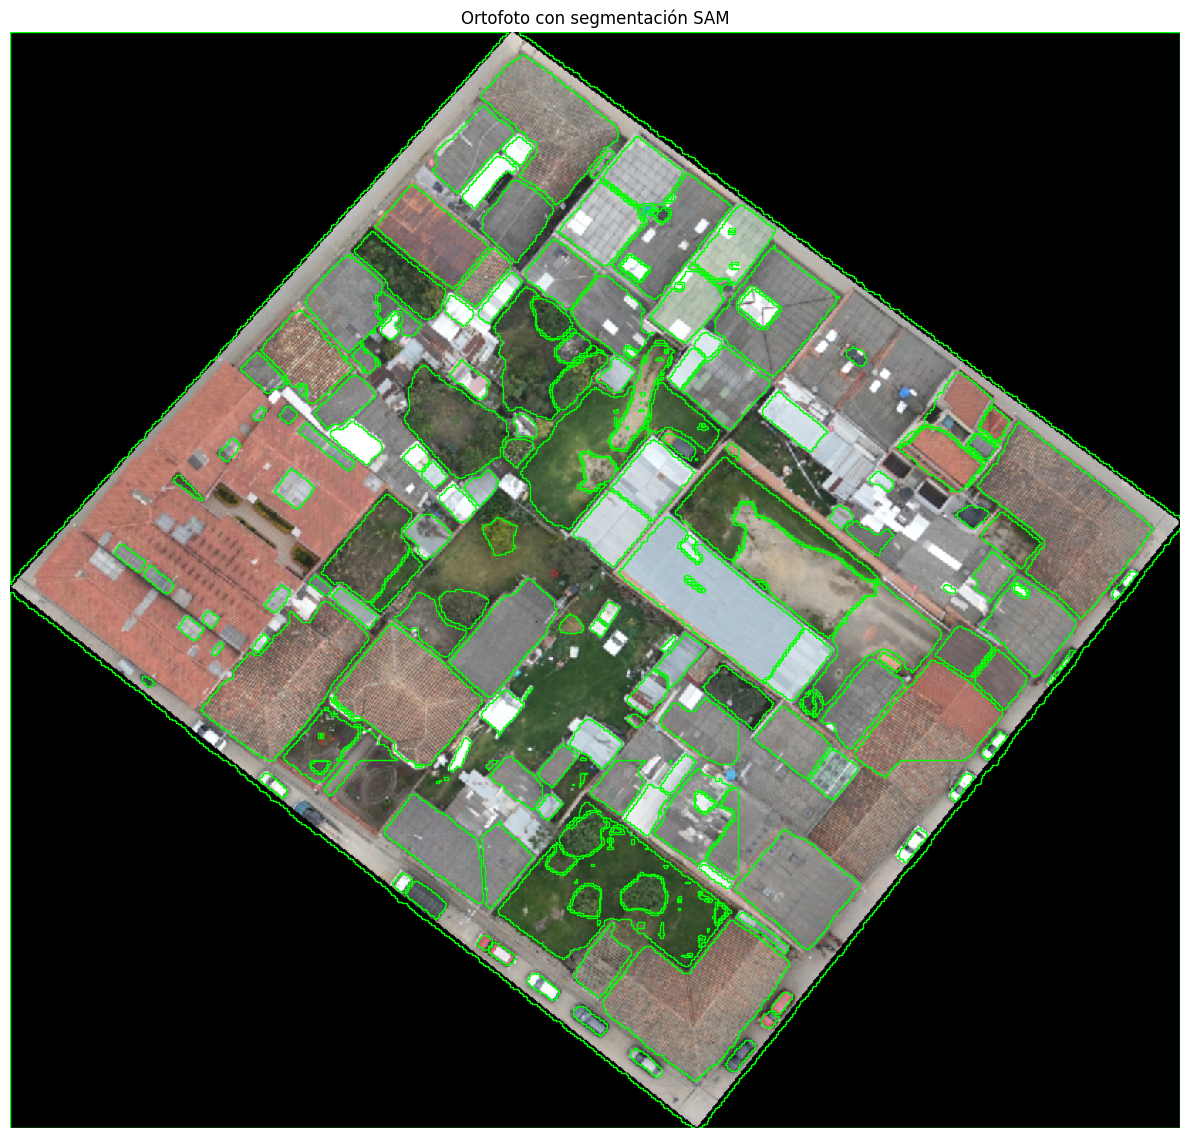

In [18]:
graficar_mascara_sobre_raster(
    raster=guasca_test,
    vector="/content/masks_guascaT/masks_guascaT.shp",
    titulo="Ortofoto con segmentación SAM"
)

## Caso de Estudio: Entrenar un modelo de detección de cubiertas en Guasca

En este caso de estudio se utilizará la herramienta **GeoAI** para la detección de cubiertas en el municipio de **Guasca**, empleando la red neuronal **Mask R-CNN**. Este enfoque combina el análisis geoespacial con técnicas avanzadas de visión por computador para identificar y segmentar cubiertas en imágenes satelitales.


### Geoai

[GeoAI](https://geoai.gishub.org) es un proyecto de código abierto que integra inteligencia artificial con análisis geoespacial en Python. Permite visualizar, procesar, segmentar y clasificar datos satelitales y vectoriales usando modelos como Segment Anything y técnicas de *deep learning*.

Es liderado por el **GeoAI Lab** de la **University of Tennessee, Knoxville**, bajo la dirección del Dr. **Qiusheng Wu**, experto en SIG y análisis geoespacial con Python.

In [19]:
%pip install geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.9/632.9 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.0/605.0 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [20]:
import zipfile
import os
import geoai

In [21]:
%%capture
!wget https://github.com/Luisafrodriguezo1/Ejercicio_-Segmentacion-/raw/refs/heads/main/train_guasca.zip
#!wget https://github.com/Luisafrodriguezo1/Ejercicio_-Segmentacion-/raw/refs/heads/main/Orto_guasca_test.tif


In [22]:
zip_path = "train_guasca.zip"
extract_folder = "train_guasca"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

In [23]:
train_raster_path = "/content/train_guasca/Orto_guasca_train.tif"
train_vector_path = "/content/train_guasca/train_guasca.shp"
test_raster_path = "/content/Orto_guasca_test.tif"

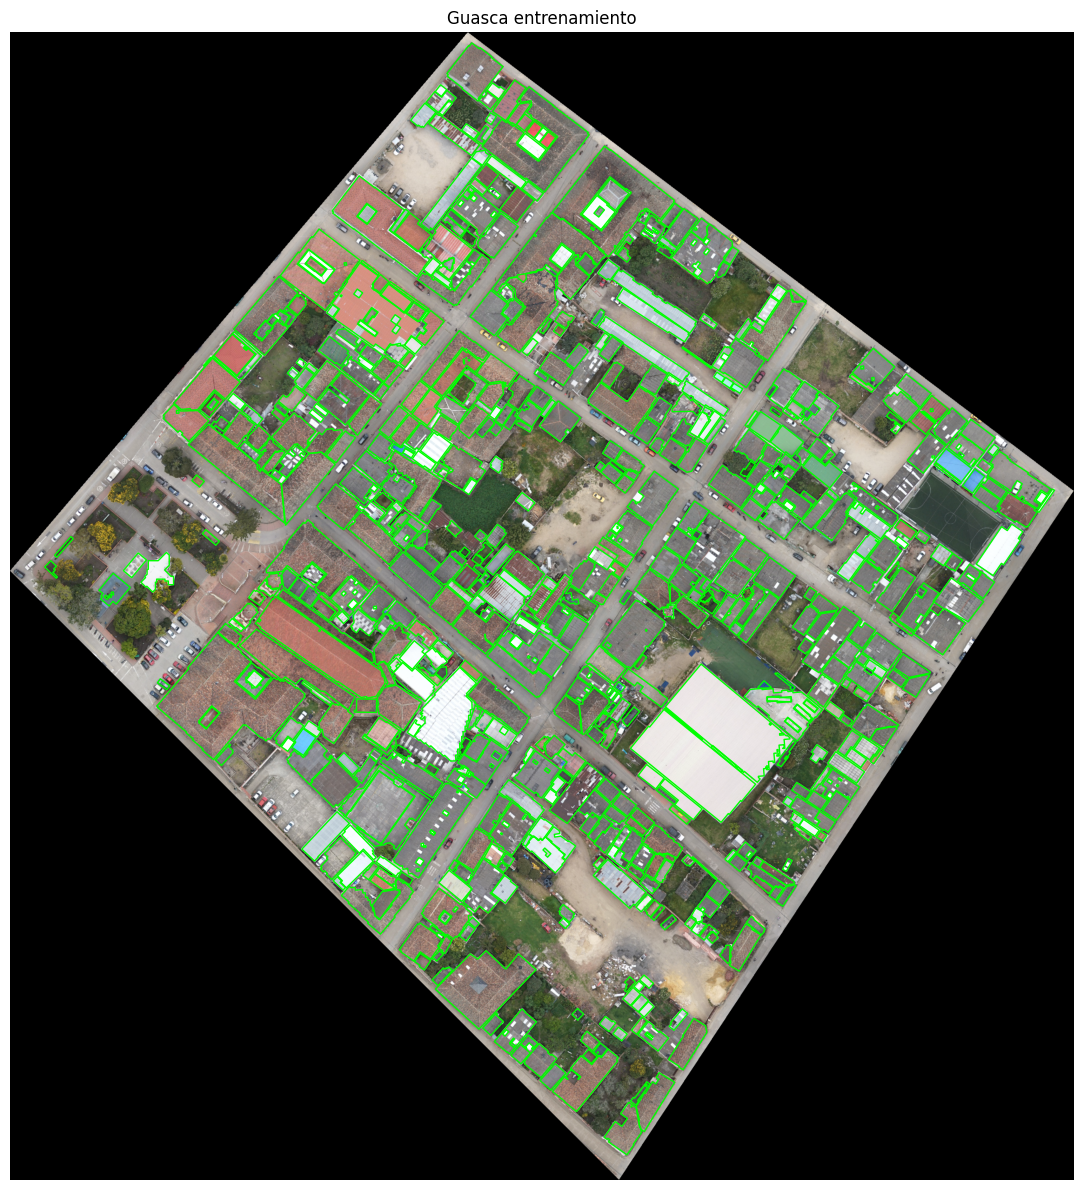

In [24]:
graficar_mascara_sobre_raster(
    raster=train_raster_path,
    vector=train_vector_path,
    titulo="Guasca entrenamiento"
)


La función `geoai.export_geotiff_tiles()` para preparar los datos de entrenamiento para un modelo de aprendizaje profundo

Esta función corta el raster de entrada (`train_raster_path`) en mosaicos pequeños (o *tiles*) junto con sus respectivas etiquetas derivadas del vector (`train_vector_path`), de la siguiente manera:

- **`in_raster`**: ruta al raster de entrada.
- **`out_folder`**: carpeta de salida donde se guardarán los tiles generados.
- **`in_class_data`**: ruta al archivo vectorial con las clases (polígonos de cubiertas).
- **`tile_size=512`**: cada tile tendrá un tamaño de 512×512 píxeles.
- **`stride=256`**: el paso entre tiles será de 256 píxeles (los tiles se superponen un 50%).
- **`buffer_radius=0`**: no se incluye área adicional (buffer) alrededor de cada tile.

In [25]:
out_folder = "output"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)


Raster info for /content/train_guasca/Orto_guasca_train.tif:
  CRS: ESRI:103599
  Dimensions: 2446 x 2639
  Resolution: (0.1500000000001523, 0.1500000000001523)
  Bands: 3
  Bounds: BoundingBox(left=4902666.8, bottom=2095587.35, right=4903033.7, top=2095983.2000000004)
Loaded 648 features from /content/train_guasca/train_guasca.shp
Vector CRS: PROJCS["MAGNA_SIRGAS_Origen_Nacional",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


Generated: 90, With features: 77: 100%|██████████| 90/90 [00:16<00:00,  5.42it/s]


------- Export Summary -------
Total tiles exported: 90
Tiles with features: 77 (85.6%)
Average feature pixels per tile: 85942.0
Output saved to: output

------- Georeference Verification -------



Al ejecutar la función `geoai.export_geotiff_tiles()`, se obtiene la siguiente información sobre los datos vectoriales y los tiles exportados:

- **CRS del vector**: `MAGNA-SIRGAS Origen Nacional`  
  El vector se encuentra en el mismo sistema de coordenadas que el raster

- **Características cargadas**: 648  
  Se detectaron 648 entidades (polígonos de cubiertas) en el archivo vectorial.

- **Advertencia**: No se encontró un campo llamado `'class'` en los atributos del vector.  
  Como resultado, se asignó automáticamente una única clase con ID `1` a todos los polígonos.

**Exportación de mosaicos (tiles)**

- **Tiles generados**: 90  
- **Tiles que contienen cubiertas (features)**: 77 (85.6%)
- **Promedio de píxeles etiquetados por tile**: 85,942
- **Carpeta de salida**: `output`

La función genera tres carpetas principales dentro del directorio de salida (`output/`), cada una con archivos correspondientes a los tiles generados:

- **`annotations/`**: contiene los archivos `.xml` con la información de anotación para cada tile, como cajs delimitadoras
  Ejemplo:  
  `xml_path = /content/output/annotations/tile_000003.xml`

- **`images/`**: contiene los fragmentos del raster original en formato `.tif`. Estos son los tiles de entrada para el modelo.  
  Ejemplo:  
  `image_path = /content/output/images/tile_000003.tif`

- **`labels/`**: contiene las máscaras de segmentación correspondientes a cada tile, también en formato `.tif`. Estas son las etiquetas del modelo.  
  Ejemplo:  
  `mask_path = /content/output/labels/tile_000003.tif`



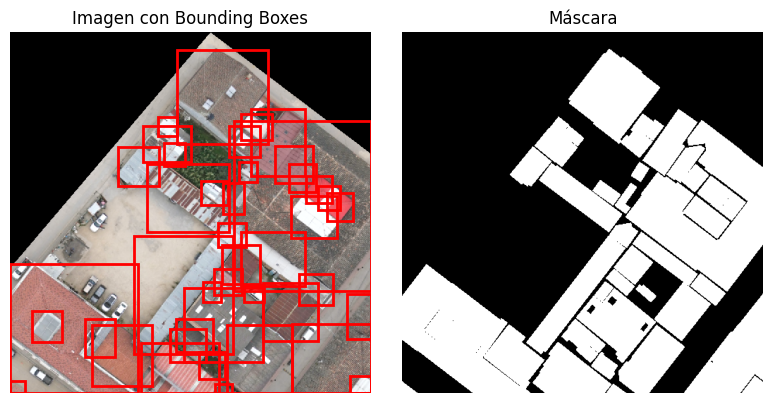

In [26]:
import xml.etree.ElementTree as ET
from matplotlib.patches import Rectangle

# Rutas a tus archivos
xml_path = "/content/output/annotations/tile_000003.xml"
image_path = "/content/output/images/tile_000003.tif"
mask_path = "/content/output/labels/tile_000003.tif"

# -------------------------------
# 1. Leer y parsear el XML
tree = ET.parse(xml_path)
root = tree.getroot()

# Extraer bounding boxes
boxes = []
for obj in root.findall("object"):
    bndbox = obj.find("bndbox")
    xmin = int(bndbox.find("xmin").text)
    ymin = int(bndbox.find("ymin").text)
    xmax = int(bndbox.find("xmax").text)
    ymax = int(bndbox.find("ymax").text)
    boxes.append((xmin, ymin, xmax, ymax))

# -------------------------------
# 2. Leer imagen RGB y máscara
with rasterio.open(image_path) as src_img:
    image = src_img.read([1, 2, 3]).transpose(1, 2, 0)  # HWC

with rasterio.open(mask_path) as src_mask:
    mask = src_mask.read(1)  # Capa única

# -------------------------------
# 3. Visualizar solo imagen con cajas y máscara
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# Imagen con bounding boxes
axs[0].imshow(image)
axs[0].set_title("Imagen con Bounding Boxes")
for xmin, ymin, xmax, ymax in boxes:
    rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                     edgecolor='red', facecolor='none', linewidth=2)
    axs[0].add_patch(rect)

# Solo la máscara
axs[1].imshow(mask, cmap="gray")
axs[1].set_title("Máscara")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()


La función `geoai.train_MaskRCNN_model()` entrena un modelo de segmentación de cubiertas utilizando la arquitectura **Mask R-CNN**. A continuación se describen los parámetros principales:

- **`output_dir`**: carpeta donde se almacenará el modelo entrenado y otros archivos generados.  
  Ejemplo: `output/models/`

- **`num_channels`**: número de bandas o canales en las imágenes de entrada. Para imágenes RGB se usa `3`.

- **`pretrained`**: si es `True`, utiliza un modelo base preentrenado (por ejemplo, en COCO) para transferir conocimiento y acelerar el entrenamiento.

- **`batch_size`**: número de imágenes que se procesan en cada paso de entrenamiento.

- **`num_epochs`**: cantidad de veces que el modelo verá todo el conjunto de entrenamiento. Un número alto generalmente mejora la precisión (con suficiente validación para evitar sobreajuste).

- **`learning_rate`**: tasa de aprendizaje del modelo, que controla cuánto se ajustan los pesos en cada paso de entrenamiento.

- **`val_split`**: proporción del conjunto de datos que se reserva para validación. Por ejemplo, `0.2` significa que el 20% se usará para validar el rendimiento del modelo.

In [27]:
geoai.train_MaskRCNN_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    num_channels=3,
    pretrained=True,
    batch_size=4,
    num_epochs=50,
    learning_rate=0.005,
    val_split=0.2,
)

Using device: cuda
Found 90 image files and 90 label files
Training on 72 images, validating on 18 images
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 211MB/s]


Epoch: 1, Batch: 1/18, Loss: 6.6183, Time: 6.23s
Epoch: 1, Batch: 11/18, Loss: 1.2600, Time: 11.64s
Epoch 1/50: Train Loss: 1.9666, Val Loss: inf, Val IoU: 0.4275
Saving best model with IoU: 0.4275
Epoch: 2, Batch: 1/18, Loss: 1.5231, Time: 4.07s
Epoch: 2, Batch: 11/18, Loss: 1.3899, Time: 11.16s
Epoch 2/50: Train Loss: 1.1712, Val Loss: inf, Val IoU: 0.5536
Saving best model with IoU: 0.5536
Epoch: 3, Batch: 1/18, Loss: 0.9118, Time: 3.52s
Epoch: 3, Batch: 11/18, Loss: 0.9325, Time: 11.89s
Epoch 3/50: Train Loss: 0.9316, Val Loss: inf, Val IoU: 0.6386
Saving best model with IoU: 0.6386
Epoch: 4, Batch: 1/18, Loss: 0.7552, Time: 3.68s
Epoch: 4, Batch: 11/18, Loss: 0.8357, Time: 11.78s
Epoch 4/50: Train Loss: 0.8167, Val Loss: inf, Val IoU: 0.6151
Epoch: 5, Batch: 1/18, Loss: 0.7530, Time: 3.97s
Epoch: 5, Batch: 11/18, Loss: 0.7379, Time: 11.72s
Epoch 5/50: Train Loss: 0.7495, Val Loss: inf, Val IoU: 0.6800
Saving best model with IoU: 0.6800
Epoch: 6, Batch: 1/18, Loss: 0.5842, Time: 3.

In [28]:
masks_path = "test_prediction.tif"
model_path = f"{out_folder}/models/best_model.pth"



La función `geoai.object_detection()` aplica un modelo previamente entrenado **Mask R-CNN** sobre un **raster de prueba** con el objetivo de **detectar y segmentar objetos** geoespaciales.

Este proceso consiste en dividir la imagen en ventanas, realizar inferencia sobre cada una usando el modelo y reconstruir una máscara de predicción completa que representa las áreas detectadas.

In [29]:
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path,
    window_size=512,
    overlap=256,
    confidence_threshold=0.5,
    batch_size=4,
    num_channels=3,
)

Processing 9 windows with size 512x512 and overlap 256...


16it [00:01,  8.34it/s]

Inference completed in 1.92 seconds
Saved prediction to test_prediction.tif


Ahora, se convierten las máscaras raster resultantes de una predicción en polígonos vectoriales simplificados y alineados ortogonalmente

In [30]:
output_path = "test_predic.geojson"
gdf = geoai.orthogonalize(masks_path, output_path, epsilon=2)

Processing 79 features...


Converting features: 100%|██████████| 79/79 [00:00<00:00, 105.04shape/s]


Saving to test_predic.geojson...
Done!


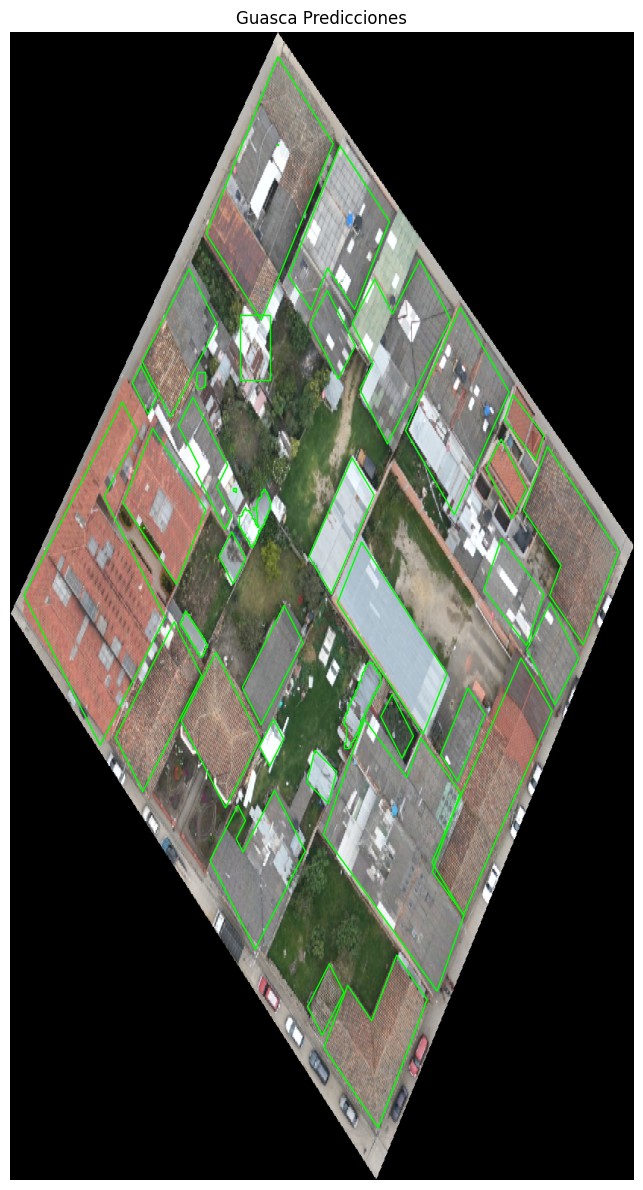

In [31]:
graficar_mascara_sobre_raster(
    raster=test_raster_path,
    vector=output_path,
    titulo="Guasca Predicciones"
)

## Análisis de Resultados o Conclusiones

El uso de GeoAI en este caso de estudio demuestra el potencial de combinar inteligencia artificial con análisis geoespacial para automatizar tareas que tradicionalmente requerían mucho tiempo, como la detección de cubiertas a partir de imágenes satelitales. A través de un flujo estructurado desde la preparación de datos, entrenamiento del modelo con Mask R-CNN, hasta la predicción y postprocesamiento ortogonalizado es posible generar resultados precisos, reutilizables y fácilmente integrables en sistemas de información geográfica (SIG).

Comparado con  SAM (Segment Anything Model), GeoAI requiere mayor preparación inicial, especialmente en la generación de etiquetas de entrenamiento, pero ofrece un control mucho más fino y resultados específicos adaptados a las necesidades del proyecto. Mientras SAM destaca por su capacidad de segmentar rápidamente cualquier objeto sin entrenamiento previo, su naturaleza generalista lo hace menos adecuado cuando se buscan salidas limpias, ortogonales y orientadas a una clase particular como las cubiertas.

## Referencias

*Wu, Q., & Osco, L. (2023). *samgeo: A Python package for segmenting geospatial data with the Segment Anything Model (SAM)*. *Journal of Open Source Software, 8*(89), 5663. https://doi.org/10.21105/joss.05663

*Osco, L. P., Wu, Q., de Lemos, E. L., Gonçalves, W. N., Ramos, A. P. M., Li, J., & Junior, J. M. (2023). *The Segment Anything Model (SAM) for remote sensing applications: From zero to one shot*. *International Journal of Applied Earth Observation and Geoinformation, 124*, 103540. https://doi.org/10.1016/j.jag.2023.103540

*Wu, Q. (2025). *GeoAI: Artificial Intelligence for Geospatial Data* [Software]. Recuperado de https://geoai.gishub.org/
